In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [6]:
x.shape

(1000, 2)

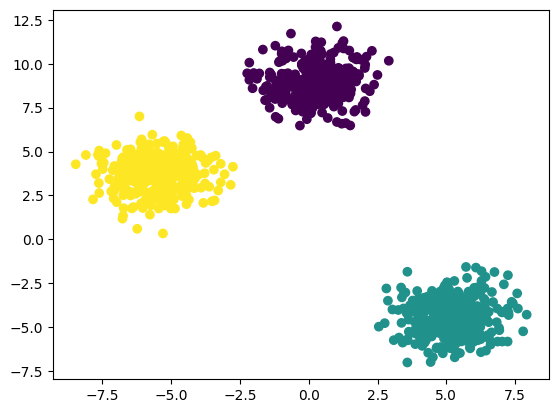

In [7]:
plt.scatter(x[:,0],x[:,1],c=y)

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Mnual Process
## Elbow Method to select the k value

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [13]:
wcss

[34827.57682552021,
 7935.437286145418,
 1319.2730531585612,
 1201.0632491141112,
 1071.8685767846764,
 854.3146617450061,
 765.5347632093475,
 665.3751914103143,
 642.4854382988688,
 545.4407567637292]

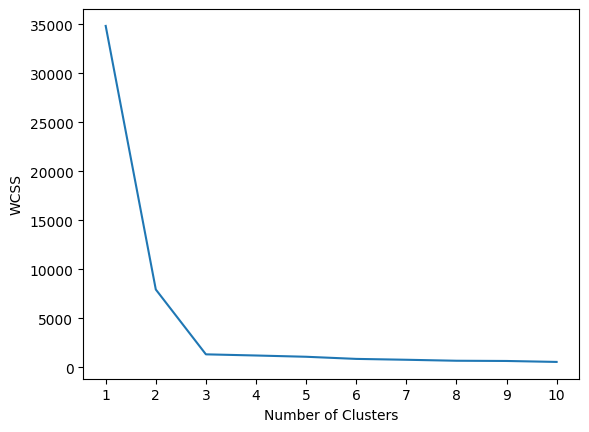

In [17]:
## plot the diagram
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [23]:
y_lables=kmeans.fit_predict(x_train) ## fit only on trianing data

In [28]:
y_lables[:9]
pd.Categorical(y_lables)

[0, 0, 0, 1, 1, ..., 1, 2, 0, 1, 0]
Length: 670
Categories (3, int32): [0, 1, 2]

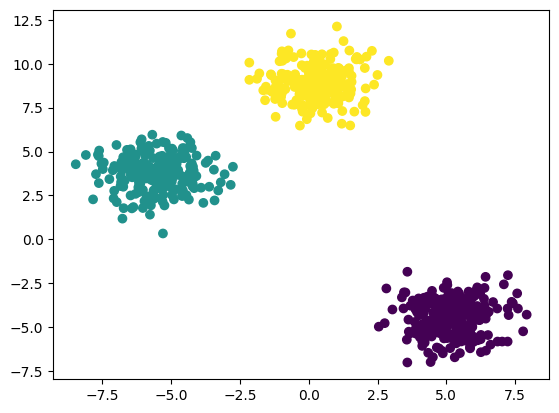

In [27]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_lables)

In [29]:
y_test_labels=kmeans.predict(x_test) # in test data we don't fit only predict the data which he leran on train data

In [31]:
y_test[:9]
pd.Categorical(y_test)

[0, 0, 0, 1, 2, ..., 0, 2, 2, 2, 0]
Length: 330
Categories (3, int64): [0, 1, 2]

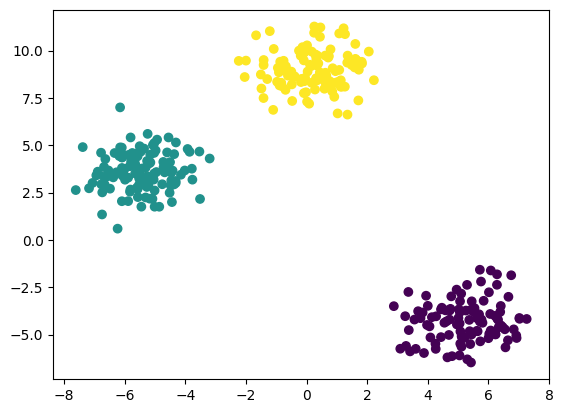

In [33]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_labels)

In [34]:
## Knee Locator : It is used to find k number automated
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [37]:
from kneed import KneeLocator

In [38]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [40]:
## Performance Metrics
## Silhoute Score
from sklearn.metrics import silhouette_score

In [43]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [44]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6433169469265496,
 0.6470203541227822,
 0.5046587604480067,
 0.346847116265304,
 0.3223417332546784,
 0.3390443904219075,
 0.3225161106571347]

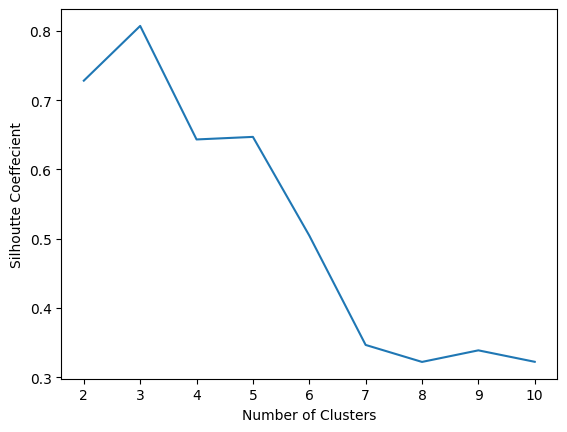

In [45]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()